In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

fake_news_path = kagglehub.competition_download('fake-news')
incorpes_glove6b200d_path = kagglehub.dataset_download('incorpes/glove6b200d')

print('Data source import complete.')


100%|██████████| 46.5M/46.5M [00:00<00:00, 91.3MB/s]

Extracting files...


100%|██████████| 259M/259M [00:02<00:00, 101MB/s]

Extracting files...


Data source import complete.


In [ ]:
#Importing libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.initializers import Constant
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.utils import to_categorical
import re
import keras
import tensorflow as tf


import io

In [ ]:
#Importing Dataset
import os
import pandas as pd

# Check if files exist in the downloaded directory
print(os.listdir(fake_news_path))

# Load dataset directly from the Kaggle download path
dataset = pd.read_csv(os.path.join(fake_news_path, 'train.csv'))
dataset.head()


['test.csv', 'train.csv', 'submit.csv']


,id,title,author,text,label
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1


In [ ]:
dataset.shape

(20800, 5)

In [ ]:
#Extracting the required columns

df = dataset[['text', 'label']]
df.head()

,text,label
0,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,Ever get the feeling your life circles the rou...,0
2,"Why the Truth Might Get You Fired October 29, ...",1
3,Videos 15 Civilians Killed In Single US Airstr...,1
4,Print \nAn Iranian woman has been sentenced to...,1


In [ ]:
df = df.dropna()
df.isnull().sum()
df.shape

(20761, 2)

In [ ]:
#Cleaning the string

def clean_str(in_str):
    in_str = str(in_str)
    # replace urls with 'url'
    in_str = re.sub(r"(https?:\/\/(?:www\.|(?!www))[a-zA-Z0-9][a-zA-Z0-9-]+[a-zA-Z0-9]\.[^\s]{2,}|www\.[a-zA-Z0-9][a-zA-Z0-9-]+[a-zA-Z0-9]\.[^\s]{2,}|https?:\/\/(?:www\.|(?!www))[a-zA-Z0-9]\.[^\s]{2,}|www\.[a-zA-Z0-9]\.[^\s]{2,})", "url", in_str)
    in_str = re.sub(r'([^\s\w]|_)+', '', in_str)
    return in_str.strip().lower()


df['text'] = df['text'].apply(clean_str)

In [ ]:
df.label.value_counts()

,count
label,
0,10387
1,10374


In [ ]:
#Reducing the size of the dataset

df_0 = df[df['label'] == 0].sample(frac=1)
df_1 = df[df['label'] == 1].sample(frac=1)

#For balancing the data of both the categories.
sample_size = 5000

data = pd.concat([df_0.head(sample_size), df_1.head(sample_size)]).sample(frac=1)
data.head()

,text,label
14754,because insanity is doing the same thing every...,1
2225,black christian leaders issue clinton letter o...,1
19610,posted on october 29 2016 by kevin ryan \nscie...,1
13888,donald trumps merry band of supporters are sur...,1
18068,mr netanyahu has presented this as a rebuff to...,1


In [ ]:
data['l'] = data['text'].apply(lambda x: len(str(x).split(' ')))
print("Mean length of the sentences: " + str(data.l.mean()))
print("Max length of the sentences: " + str(data.l.max()))
print("Standard deviation of length of the sentences: " + str(data.l.std()))

Mean length of the sentences: 784.249
Max length of the sentences: 20897
Standard deviation of length of the sentences: 922.0685079929492


In [ ]:
data.shape

(10000, 3)

In [ ]:
sequence_length = data.l.max()

In [ ]:
#Tokenizing

max_features = 10000

tokenizer = Tokenizer(max_features, split=' ', oov_token='<unw>')
tokenizer.fit_on_texts(data['text'].values)


X = tokenizer.texts_to_sequences(data['text'].values)


X = pad_sequences(X, sequence_length)

y = pd.get_dummies(data['label']).values


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print("Test set size " + str(len(X_test)))

Test set size 2000


In [ ]:
print(os.listdir(incorpes_glove6b200d_path))

['glove.6B.200d.txt']


In [ ]:
#Embedding using GloVe embeddings
import os
import io
import numpy as np

# Define the correct path to the GloVe file
glove_path = os.path.join(incorpes_glove6b200d_path, 'glove.6B.200d.txt')

embeddings_index = {}
with io.open(glove_path, encoding='utf8') as f:
  for line in f:
      values = line.split()
      word = values[0]
      coefs = np.asarray(values[1:], dtype='float32')
      embeddings_index[word] = coefs
  f.close()

print('Found %s word vectors.' % len(embeddings_index))

Found 400000 word vectors.


In [ ]:
word_index = tokenizer.word_index
print('Found %s unique tokens.' % len(word_index))

Found 145918 unique tokens.


In [ ]:
embedding_dim = 200
num_words = min(max_features, len(word_index)) + 1
print(num_words)

embedding_matrix = np.zeros((num_words, embedding_dim))

for word, i in word_index.items():
    if i > max_features:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:

        embedding_matrix[i] = embedding_vector
    else:

        embedding_matrix[i] = np.random.randn(embedding_dim)

10001


In [ ]:
#Model for the CNN architecture

num_filters = 100

inputs_3 = Input(shape=(sequence_length,), dtype='int32')
embedding_layer_3 = Embedding(num_words,
                            embedding_dim,
                            embeddings_initializer=Constant(embedding_matrix),
                            input_length=sequence_length,
                            trainable=True)(inputs_3)

reshape_3 = Reshape((sequence_length, embedding_dim, 1))(embedding_layer_3)

# note the relu activation
conv_0_3 = Conv2D(num_filters, kernel_size=(3, embedding_dim), activation='relu', kernel_regularizer=keras.regularizers.l2(3))(reshape_3)
conv_1_3 = Conv2D(num_filters, kernel_size=(4, embedding_dim), activation='relu', kernel_regularizer=keras.regularizers.l2(3))(reshape_3)
conv_2_3 = Conv2D(num_filters, kernel_size=(5, embedding_dim), activation='relu', kernel_regularizer=keras.regularizers.l2(3))(reshape_3)

maxpool_0_3 = MaxPool2D(pool_size=(sequence_length - 3 + 1, 1), strides=(1,1), padding='valid')(conv_0_3)
maxpool_1_3 = MaxPool2D(pool_size=(sequence_length - 4 + 1, 1), strides=(1,1), padding='valid')(conv_1_3)
maxpool_2_3 = MaxPool2D(pool_size=(sequence_length - 5 + 1, 1), strides=(1,1), padding='valid')(conv_2_3)

concatenated_tensor_3 = Concatenate(axis=1)([maxpool_0_3, maxpool_1_3, maxpool_2_3])
flatten_3 = Flatten()(concatenated_tensor_3)

dropout_3 = Dropout(0.5)(flatten_3)
output_3 = Dense(units=2, activation='softmax')(dropout_3)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model_3 = Model(inputs=inputs_3, outputs=output_3)
model_3.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model_3.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 20897)          │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding (Embedding)     │ (None, 20897, 200)     │      2,000,200 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape (Reshape)         │ (None, 20897, 200, 1)  │              0 │ embedding[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 20895, 1, 100)  │         60,100 │ reshape[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 20894, 1, 100)  │         80,100 │ reshape[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 20893, 1, 100)  │        100,100 │ reshape[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 1, 1, 100)      │              0 │ conv2d[0][0]           │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 1, 1, 100)      │              0 │ conv2d_1[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 1, 1, 100)      │              0 │ conv2d_2[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 3, 1, 100)      │              0 │ max_pooling2d[0][0],   │
│                           │                        │                │ max_pooling2d_1[0][0], │
│                           │                        │                │ max_pooling2d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten (Flatten)         │ (None, 300)            │              0 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 300)            │              0 │ flatten[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 2)              │            602 │ dropout[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 2,241,102 (8.55 MB)

 Trainable params: 2,241,102 (8.55 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
#Training the model

batch_size = 16
history_3 = model_3.fit(X_train, y_train, epochs=10, batch_size=batch_size, verbose=1, validation_split=0.2, shuffle = True)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 446s 548ms/step - accuracy: 0.6359 - loss: 1.8025 - val_accuracy: 0.7194 - val_loss: 0.9086
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 215s 394ms/step - accuracy: 0.8481 - loss: 0.7684 - val_accuracy: 0.8350 - val_loss: 0.8135
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 202s 393ms/step - accuracy: 0.8806 - loss: 0.7353 - val_accuracy: 0.9044 - val_loss: 0.6410
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 157s 393ms/step - accuracy: 0.8745 - loss: 0.7617 - val_accuracy: 0.8863 - val_loss: 0.9352
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 202s 393ms/step - accuracy: 0.8903 - loss: 0.7412 - val_accuracy: 0.9075 - val_loss: 0.6721
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 202s 393ms/step - accuracy: 0.9157 - loss: 0.6744 - val_accuracy: 0.9156 - val_loss: 0.6571
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 202s 393ms/step - accuracy: 0.9098 - loss: 0.7113 - val_accuracy: 0.9256 - val_loss: 0.6631
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 202s 393ms/step - accuracy: 0.9115 -

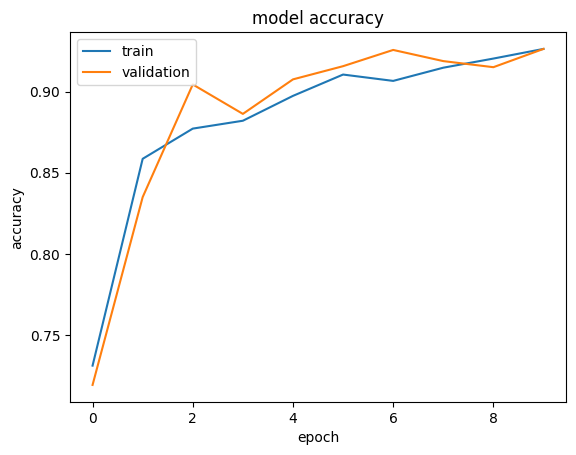

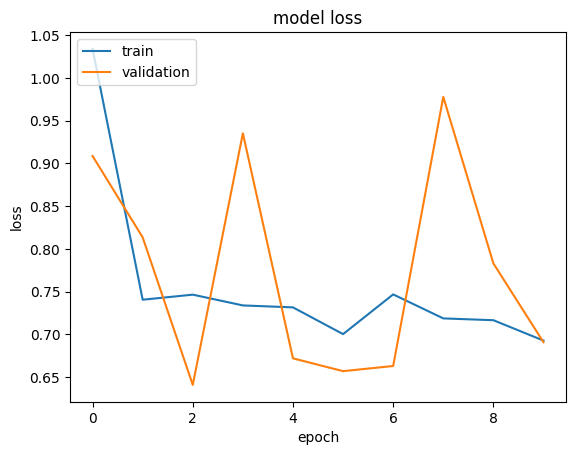

In [ ]:
#Plotting Graph

plt.plot(history_3.history['accuracy'])
plt.plot(history_3.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

plt.plot(history_3.history['loss'])
plt.plot(history_3.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [ ]:
y_hat_3 = model_3.predict(X_test)
accuracy_score(list(map(lambda x: np.argmax(x), y_test)), list(map(lambda x: np.argmax(x), y_hat_3)))

63/63 ━━━━━━━━━━━━━━━━━━━━ 78s 218ms/step


0.9215

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [ ]:
y_pred = np.argmax(y_hat_3, axis=1)  # Convert probabilities to class labels
y_true = np.argmax(y_test, axis=1)   # True labels

In [ ]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.87      0.92       980
           1       0.89      0.97      0.93      1020

    accuracy                           0.92      2000
   macro avg       0.93      0.92      0.92      2000
weighted avg       0.93      0.92      0.92      2000



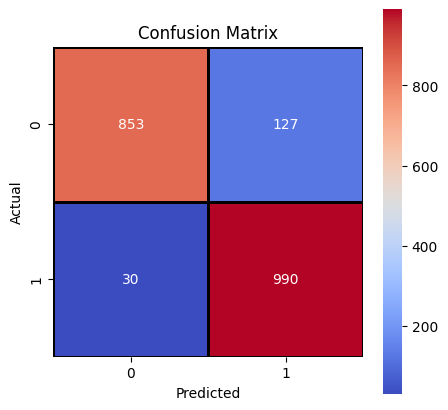

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', linewidths=1, linecolor='black', square=True)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 214ms/step


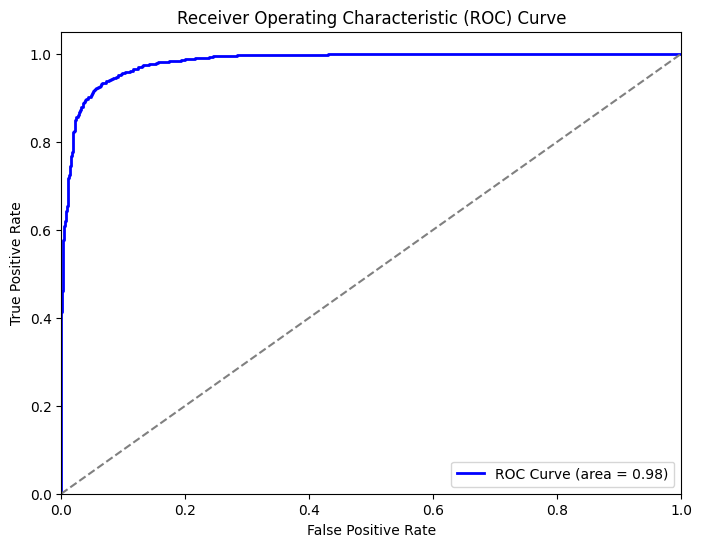

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities
y_probs = model_3.predict(X_test)  # Get probability scores
y_true = y_test[:, 1]  # Select the second column (class 1 probabilities)

# Compute ROC curve and AUC score
fpr, tpr, _ = roc_curve(y_true, y_probs[:, 1])
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random classifier
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

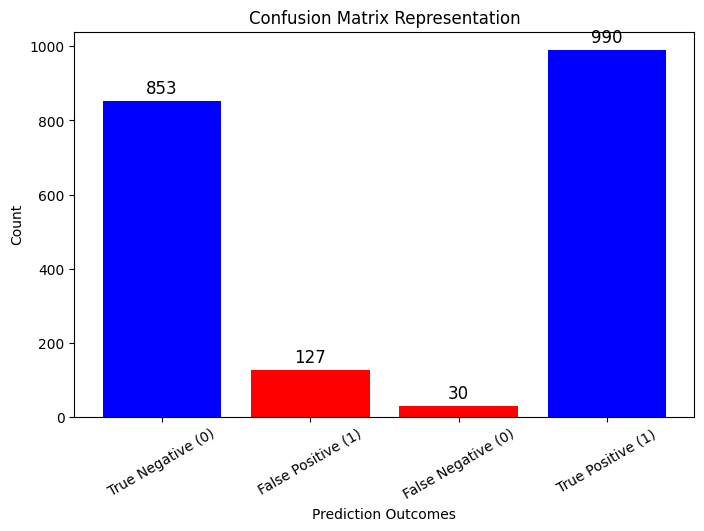

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Confusion matrix values
categories = ['True Negative (0)', 'False Positive (1)', 'False Negative (0)', 'True Positive (1)']
values = [853, 127, 30, 990]

# Create bar plot
plt.figure(figsize=(8,5))
bars = plt.bar(categories, values, color=['blue', 'red', 'red', 'blue'])

# Add text labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 20, yval, ha='center', fontsize=12)

# Labels and title
plt.xlabel("Prediction Outcomes")
plt.ylabel("Count")
plt.title("Confusion Matrix Representation")

plt.xticks(rotation=30)
plt.show()